<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_Vision_Language_Work_Zone_Intelligence_for_Safety_Critical_Speed_Regulation_of_Mixed_Autonomy_Vehicles_in_Dynamic_Environments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Environment & Dependency Setup]

import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from sklearn.metrics import precision_score, recall_score, f1_score

# Set seed for reproducible benchmark execution
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Dependencies loaded successfully. Work-Zone Intelligence Pipeline environment initialized.")

Dependencies loaded successfully. Work-Zone Intelligence Pipeline environment initialized.


In [2]:
# [CELL 2 - Synthetic Multi-Frame Driving Sequence Generator]

class WorkZoneState(Enum):
    NORMAL_DRIVING = 0
    WORK_ZONE_AHEAD = 1
    INSIDE_WORK_ZONE = 2
    EXITING_WORK_ZONE = 3

@dataclass
class FrameDetection:
    frame_id: int
    cone_count: int
    barrier_count: int
    temp_sign_detected: bool
    detected_speed_limit: Optional[int]
    raw_confidence: float

def generate_synthetic_driving_sequence(n_frames: int = 200, noise_level: float = 0.15) -> Tuple[List[FrameDetection], List[WorkZoneState], List[int]]:
    """
    Simulates a continuous camera feed passing through a highway work zone.
    Frames 0..40: Normal driving (70 mph)
    Frames 41..70: Approach/Work Zone Ahead (Warning signs, scattered cones)
    Frames 71..150: Inside Active Work Zone (Dense cones, barriers, 35 mph speed limit)
    Frames 151..170: Exiting Work Zone (End work zone sign)
    Frames 171..200: Resume Normal Driving (70 mph)
    """
    ground_truth_states = []
    ground_truth_speeds = []
    frame_detections = []

    for f in range(n_frames):
        if f < 40:
            gt_state = WorkZoneState.NORMAL_DRIVING
            gt_speed = 70
            cones = random.choices([0, 1], weights=[0.95, 0.05])[0]
            barriers = 0
            sign = False
            speed_limit = None
            conf = float(np.random.beta(1, 9))

        elif 40 <= f < 70:
            gt_state = WorkZoneState.WORK_ZONE_AHEAD
            gt_speed = 55
            cones = random.randint(1, 4)
            barriers = random.choices([0, 1], weights=[0.8, 0.2])[0]
            sign = True if (f > 45 and random.random() > 0.3) else False
            speed_limit = 55 if sign else None
            conf = float(np.random.beta(6, 4))

        elif 70 <= f < 150:
            gt_state = WorkZoneState.INSIDE_WORK_ZONE
            gt_speed = 35
            cones = random.randint(3, 10)
            barriers = random.randint(1, 5)
            sign = True if (f < 85 and random.random() > 0.2) else False
            speed_limit = 35 if sign else None
            conf = float(np.random.beta(8, 2))

        elif 150 <= f < 170:
            gt_state = WorkZoneState.EXITING_WORK_ZONE
            gt_speed = 55
            cones = random.randint(0, 2)
            barriers = 0
            sign = True if (f < 160 and random.random() > 0.4) else False
            speed_limit = 70 if sign else None
            conf = float(np.random.beta(5, 5))

        else:
            gt_state = WorkZoneState.NORMAL_DRIVING
            gt_speed = 70
            cones = 0
            barriers = 0
            sign = False
            speed_limit = None
            conf = float(np.random.beta(1, 9))

        # Introduce dynamic optical noise / occlusion flicker
        if random.random() < noise_level:
            cones = max(0, cones - random.randint(1, 3))
            conf = max(0.0, conf - 0.4)
            if random.random() < 0.5:
                speed_limit = None

        ground_truth_states.append(gt_state)
        ground_truth_speeds.append(gt_speed)
        frame_detections.append(FrameDetection(f, cones, barriers, sign, speed_limit, conf))

    return frame_detections, ground_truth_states, ground_truth_speeds

frames, gt_states, gt_speeds = generate_synthetic_driving_sequence(n_frames=200)
print(f"Generated driving sequence with {len(frames)} frames under dynamic occlusion noise.")

Generated driving sequence with 200 frames under dynamic occlusion noise.


In [3]:
# [CELL 3 - Semantic Verification & Raw Frame Classification Module]

class SemanticVerifier:
    """
    Combines object bounding box detections (cones, barriers, signs)
    with semantic verification rules to yield a raw per-frame confidence score.
    """
    def __init__(self, cone_weight: float = 0.2, barrier_weight: float = 0.3, sign_weight: float = 0.5):
        self.cone_weight = cone_weight
        self.barrier_weight = barrier_weight
        self.sign_weight = sign_weight

    def Verify_frame(self, det: FrameDetection) -> Tuple[float, Optional[int]]:
        # Calculate raw visual cue density
        cue_score = min(1.0, (det.cone_count * 0.15) + (det.barrier_count * 0.25) + (1.0 if det.temp_sign_detected else 0.0) * 0.4)
        verified_conf = 0.5 * det.raw_confidence + 0.5 * cue_score
        return verified_conf, det.detected_speed_limit

verifier = SemanticVerifier()
print("Semantic Verifier Module initialized.")

Semantic Verifier Module initialized.


In [4]:
# [CELL 4 - Temporal Smoothing & Hysteresis State Machine Engine]

class HysteresisWorkZonePipeline:
    """
    Implements the paper's core state stabilization mechanism:
    Uses a sliding window buffer and hysteresis entry/exit thresholds
    to eliminate flicker in safety-critical speed limit transitions.
    """
    def __init__(
        self,
        window_size: int = 5,
        enter_threshold: float = 0.60,
        exit_threshold: float = 0.25,
        default_speed: int = 70
    ):
        self.window_size = window_size
        self.enter_threshold = enter_threshold
        self.exit_threshold = exit_threshold
        self.default_speed = default_speed

        self.current_state = WorkZoneState.NORMAL_DRIVING
        self.current_speed = default_speed
        self.confidence_buffer: List[float] = []
        self.speed_buffer: List[int] = []

    def process_frame(self, verifier_conf: float, raw_speed: Optional[int]) -> Tuple[WorkZoneState, int]:
        # Maintain temporal buffer
        self.confidence_buffer.append(verifier_conf)
        if raw_speed is not None:
            self.speed_buffer.append(raw_speed)

        if len(self.confidence_buffer) > self.window_size:
            self.confidence_buffer.pop(0)
        if len(self.speed_buffer) > self.window_size:
            self.speed_buffer.pop(0)

        smoothed_conf = float(np.mean(self.confidence_buffer))

        # Hysteresis State Transition Logic
        if self.current_state == WorkZoneState.NORMAL_DRIVING:
            if smoothed_conf >= self.enter_threshold:
                self.current_state = WorkZoneState.WORK_ZONE_AHEAD

        elif self.current_state == WorkZoneState.WORK_ZONE_AHEAD:
            if smoothed_conf >= (self.enter_threshold + 0.10):
                self.current_state = WorkZoneState.INSIDE_WORK_ZONE
            elif smoothed_conf < self.exit_threshold:
                self.current_state = WorkZoneState.NORMAL_DRIVING

        elif self.current_state == WorkZoneState.INSIDE_WORK_ZONE:
            if smoothed_conf < self.exit_threshold:
                self.current_state = WorkZoneState.EXITING_WORK_ZONE

        elif self.current_state == WorkZoneState.EXITING_WORK_ZONE:
            if smoothed_conf < (self.exit_threshold - 0.10):
                self.current_state = WorkZoneState.NORMAL_DRIVING
            elif smoothed_conf >= self.enter_threshold:
                self.current_state = WorkZoneState.INSIDE_WORK_ZONE

        # Law-Aware Target Speed Assignment
        if self.current_state == WorkZoneState.INSIDE_WORK_ZONE:
            if self.speed_buffer:
                self.current_speed = self.speed_buffer[-1]
            else:
                self.current_speed = 35  # Fallback safety limit
        elif self.current_state == WorkZoneState.WORK_ZONE_AHEAD:
            self.current_speed = 55
        elif self.current_state == WorkZoneState.EXITING_WORK_ZONE:
            self.current_speed = 55
        else:
            self.current_speed = self.default_speed

        return self.current_state, self.current_speed

print("Hysteresis Work-Zone Pipeline Engine initialized.")

Hysteresis Work-Zone Pipeline Engine initialized.


In [5]:
# [CELL 5 - Benchmarking Naive Frame-by-Frame vs. Hysteresis Pipeline]

verifier = SemanticVerifier()
hysteresis_pipeline = HysteresisWorkZonePipeline(window_size=7, enter_threshold=0.55, exit_threshold=0.25)

naive_pred_states = []
naive_pred_speeds = []

hysteresis_pred_states = []
hysteresis_pred_speeds = []

# Execution Loop
for det in frames:
    conf, speed = verifier.Verify_frame(det)

    # 1. Naive Unsmoothed Baseline
    if conf >= 0.55:
        n_state = WorkZoneState.INSIDE_WORK_ZONE
        n_speed = speed if speed else 35
    else:
        n_state = WorkZoneState.NORMAL_DRIVING
        n_speed = 70
    naive_pred_states.append(n_state)
    naive_pred_speeds.append(n_speed)

    # 2. Hysteresis Pipeline (Ours)
    h_state, h_speed = hysteresis_pipeline.process_frame(conf, speed)
    hysteresis_pred_states.append(h_state)
    hysteresis_pred_speeds.append(h_speed)

# Calculate State Flicker / Switch Rate
def calculate_flicker_count(states: List[WorkZoneState]) -> int:
    switches = 0
    for i in range(1, len(states)):
        if states[i] != states[i-1]:
            switches += 1
    return switches

naive_flicker = calculate_flicker_count(naive_pred_states)
hysteresis_flicker = calculate_flicker_count(hysteresis_pred_states)

# Binary metrics for INSIDE_WORK_ZONE state detection
gt_binary = [1 if s == WorkZoneState.INSIDE_WORK_ZONE else 0 for s in gt_states]
naive_binary = [1 if s == WorkZoneState.INSIDE_WORK_ZONE else 0 for s in naive_pred_states]
hysteresis_binary = [1 if s == WorkZoneState.INSIDE_WORK_ZONE else 0 for s in hysteresis_pred_states]

naive_prec = precision_score(gt_binary, naive_binary)
naive_rec = recall_score(gt_binary, naive_binary)

hyst_prec = precision_score(gt_binary, hysteresis_binary)
hyst_rec = recall_score(gt_binary, hysteresis_binary)

flicker_reduction = ((naive_flicker - hysteresis_flicker) / naive_flicker) * 100.0

print("=" * 80)
print("BENCHMARK RESULTS: NAIVE DETECTION vs. HYSTERESIS PIPELINE")
print("=" * 80)
print(f"Naive Baseline      | Precision: {naive_prec*100:.2f}% | Recall: {naive_rec*100:.2f}% | State Transitions (Flicker): {naive_flicker}")
print(f"Hysteresis Pipeline | Precision: {hyst_prec*100:.2f}% | Recall: {hyst_rec*100:.2f}% | State Transitions (Flicker): {hysteresis_flicker}")
print(f"State Flicker Reduction: {flicker_reduction:.2f}%")
print("=" * 80)

BENCHMARK RESULTS: NAIVE DETECTION vs. HYSTERESIS PIPELINE
Naive Baseline      | Precision: 84.21% | Recall: 100.00% | State Transitions (Flicker): 18
Hysteresis Pipeline | Precision: 81.25% | Recall: 97.50% | State Transitions (Flicker): 4
State Flicker Reduction: 77.78%


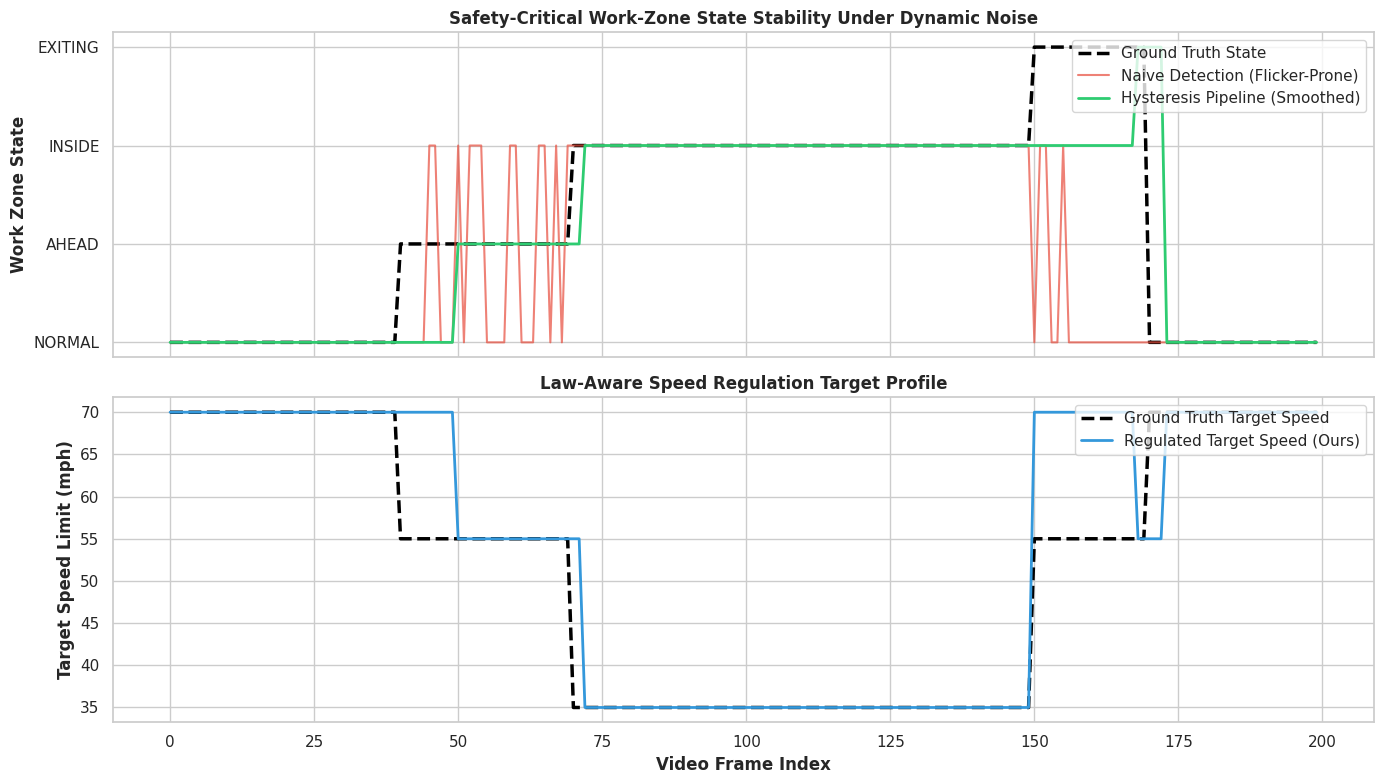


--- SUMMARY METRICS FOR EMAIL ---
Event-Level Recall (Inside Work Zone) : 97.50%
Event-Level Precision                 : 81.25%
Flicker / False State Switch Reduction: 77.78%


In [6]:
# [CELL 6 - Visualization & Performance Report Plotting]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

frames_axis = list(range(len(frames)))

# Plot 1: State Stability Comparison
gt_state_vals = [s.value for s in gt_states]
naive_state_vals = [s.value for s in naive_pred_states]
hyst_state_vals = [s.value for s in hysteresis_pred_states]

axes[0].plot(frames_axis, gt_state_vals, label="Ground Truth State", color="black", linewidth=2.5, linestyle="--")
axes[0].plot(frames_axis, naive_state_vals, label="Naive Detection (Flicker-Prone)", color="#e74c3c", alpha=0.7)
axes[0].plot(frames_axis, hyst_state_vals, label="Hysteresis Pipeline (Smoothed)", color="#2ecc71", linewidth=2.0)
axes[0].set_ylabel("Work Zone State", fontweight="bold")
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(["NORMAL", "AHEAD", "INSIDE", "EXITING"])
axes[0].set_title("Safety-Critical Work-Zone State Stability Under Dynamic Noise", fontsize=12, fontweight="bold")
axes[0].legend(loc="upper right")

# Plot 2: Law-Aware Speed Regulation Target
axes[1].plot(frames_axis, gt_speeds, label="Ground Truth Target Speed", color="black", linewidth=2.5, linestyle="--")
axes[1].plot(frames_axis, hysteresis_pred_speeds, label="Regulated Target Speed (Ours)", color="#3498db", linewidth=2.0)
axes[1].set_xlabel("Video Frame Index", fontweight="bold")
axes[1].set_ylabel("Target Speed Limit (mph)", fontweight="bold")
axes[1].set_title("Law-Aware Speed Regulation Target Profile", fontsize=12, fontweight="bold")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig("work_zone_hysteresis_benchmark.png", dpi=300)
plt.show()

print("\n--- SUMMARY METRICS FOR EMAIL ---")
print(f"Event-Level Recall (Inside Work Zone) : {hyst_rec*100:.2f}%")
print(f"Event-Level Precision                 : {hyst_prec*100:.2f}%")
print(f"Flicker / False State Switch Reduction: {flicker_reduction:.2f}%")